# Numerical Simulation Laboratory (NSL) 

## Lecture 01: Monte Carlo Methods

A Monte Carlo method deliberately uses random numbers in a calculation that has a stochastic process structure, a sequence of states whose evolution is determined by random events. In a computer simulation we talk about pseudo-random numbers. The aim of a Monte Carlo method is to provide a solution of a non-probabilistic problem by probabilistic methods.

### The Central Limit Theorem (CLT)

Given $N$ indipendent and identically distributed (i.i.d.) random variables $\{x_i\}_{i=1}^N$, we have
$$p(x_1,...,x_N) = \prod_{i=1}^N = p(x_i)$$ 
$$\langle x_1\rangle = ... = \langle x_N\rangle =: \mu$$ 
If $\langle x_1^2\rangle = ... \langle x_N^2\rangle =: \sigma^2 < \infty$, then pdfs of $A_N=\frac{1}{N}\sum_{i=1}^N x_i$ and $S_N=\sum_{i=1}^N x_i$, as $N$ tends to $\infty$, are such that
$$\langle A_N\rangle = \mu \, \,  , \, \, \langle S_N\rangle = \mu N$$
$$\sigma_{A_N}^2 = \frac{\sigma^2}{N} \, \, , \, \, \sigma_{S_N}^2 = N \sigma^2$$
$$\lim_{N \to \infty} p_N(A_N) = \frac{\exp{-[\frac{(A_N - \mu)^2}{2\sigma_{A_N}^2}]}}{\sqrt{2 \pi \sigma_{A_N}^2}} \, \, , \, \, \lim_{N \to \infty} p_N(S_N) = \frac{\exp{-[\frac{(S_N - \mu N)^2}{2\sigma_{S_N}^2}]}}{\sqrt{2 \pi \sigma_{S_N}^2}}$$

### Data Blocking Method

Data blocking is a statistical technique used to estimate the uncertainty of sequential time-correlated data. By dividing a continuous dataset into smaller, indipendent chunks, it prevents the underestimation of error that tipically occurs when standard variance formulas are blindly applied to dependent points. Blocks have to be large enough to be considered indipendent of one another. Here's how the technique works:


(i) *Partitioning:* the dataset of size $N$ is divided into $n_b$ contihuous blocks. Each block contains exactly $B$ data points ($N = B \times n_b$).

(ii) *Block Averaging:* the mean of the observable is calculated for each individual block. $\bar{x}_i$ is considered the mean of the block $i$.

(iii) *Blocks Variance Estimation:* Treating each $\bar{x}_i$ as an indipendent measurement, the variance of block averages is $\sigma_B^2 = \frac{1}{n_b-1}\sum_{i=1}^{n_b} (\bar{x}_i - \mu)^2$, where $\mu$ is the global mean of the entire dataset.

(iv) *Uncertainty Estimation:* the final uncertainty (standard error) of the global mean is estimated by dividing the block variance by the number of blocks: $\sigma_{mean}=\sqrt{\frac{\sigma_B^2}{n_b}}$.

### $\chi ^2$ test

Pearson's cumulative test statistic $\chi^2$ is a measure of the error between observations, $O_i$, and expected values, $E_i$:
$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}$$
The numerator is a squared distance between observations, $O_i$, and expected values, $E_i$, and thus should be compared (at the denominator) with the expected squared fluctuations (variance) of the relative distribution. Why variance = $E_i$? 
The probability of getting exactly $k$ (independent) successes, each one with probability $p$, in $n$ trials is given by the Binomial distribution (see <a href="https://en.wikipedia.org/wiki/Binomial_distribution">this Wikipedia link</a>):
$$Pr(X=k) = {{n}\choose{k}} p^k (1-p)^{n-k} = \frac{n!}{k! (n-k)!} p^k (1-p)^{n-k}$$
The average of the Binomial distribution is $\langle X \rangle = np$, the variance is: $\sigma^2 = np (1-p)$. Thus if $p$ is small we have that $\sigma^2 \simeq np$, that is $\sigma^2 \simeq \langle X \rangle$ and this explains the denominator $E_i$ in $\chi^2$.

### Exercise 01.1
- Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:

1. $\langle r \rangle = \int_0^1 r dr = 1/2$. Make a picture of the estimation of $\langle r \rangle$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties).

2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$(see below: Computing statistical uncertainties).

The hypothesis is that the numbers $r$ are drawn from a uniform distribution. In Statistics we cannot prove that some random events are drawn from a particular distribution (Note, in fact, that such hypothesis is false: pseudo-random numbers are drawn from a deterministic algorithm!); we can try to estimate the probability that $r$ **are not** drawn from a uniform distribution. If this probability is low, we can safely reject this last hypothesis.


3. Divide $[0,1]$ into $M$ identical sub-intervals and implement the $\chi^2$ test. Obviously, the number of expected events observed in each sub-interval after $n$ *throws*, according to a uniform distribution, is $np = n\times 1/M= n/M$. Fix $M=10^2$ and use for $n$ the first $10^4$ pseudo-random numbers, then the successive $10^4$ pseudo-random numbers, and so on ... 100 times. Plot $\chi^2_j$ for $j=1, ..., 100$. In this case the chi-square statistic is:
$$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$
We should expect on average that $(n_i - n/M)^2 \simeq n/M$ and thus $\chi^2 \simeq 100$, i.e. the number of sub-intervals.
A larger value of $\chi^2$ indicates that the hypothesis ($n_i$ are drawn from a uniform distribution) is rather unlikely ... but before judging, you could compare the histogram of the values obtained for $\chi^2_j$ with the true probability distribution (see: <a href="https://en.wikipedia.org/wiki/Chi-squared_distribution">this Wikipedia link</a>).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from scipy.stats import norm
from scipy.optimize import curve_fit

In [2]:
plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.3)

### Integral evaluation

A Monte Carlo simulation has been employed to for the evaluation of the integral $\langle r\rangle = \int_{0}^1 r dr = \frac{1}{2}$. We performed a $M=10^4$ throws using a pseudonumber generator sampled froma uniform distribution between $[0,1)$. We used the Data Blocking method to mitigate correlations and to give a robust evaluation of statistical uncertainties. We divided the total sample in $N=100$ blocks, each one containing $L=100$ points.

The following graphs show the convergence of the progressive averages for the integral and the variance $\sigma^2 = \int_0^1 (r-\frac{1}{2})^2 dr = \frac{1}{12}$. There are also represented their statistical uncertainties as a function of the total number of throws.

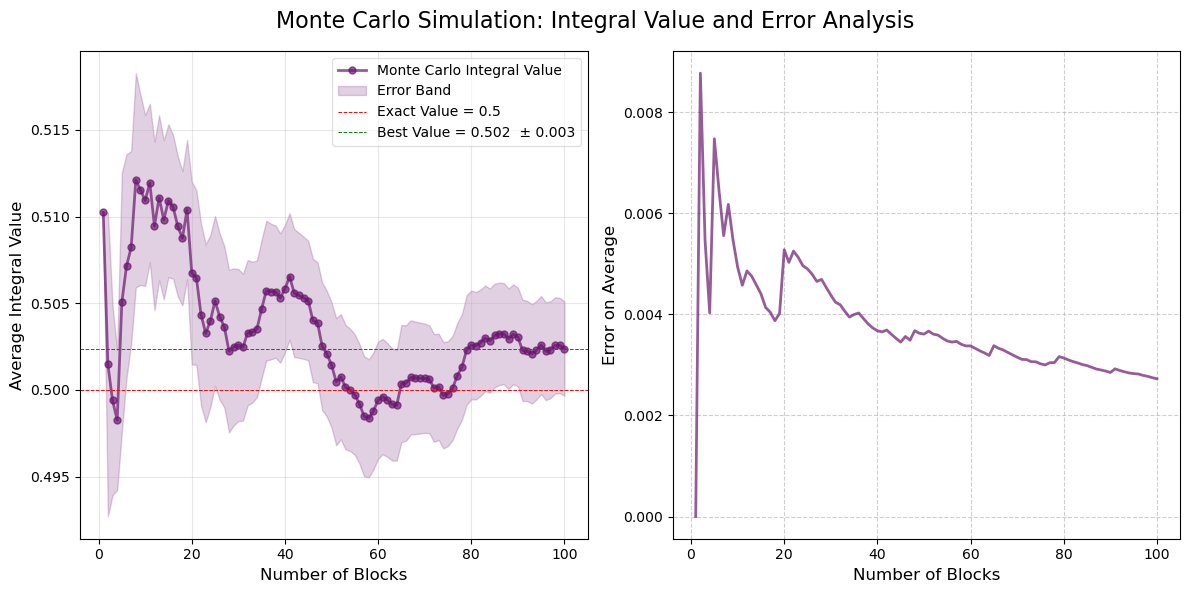

In [3]:
# Integral Value and its error
avg = "ex01.1/out_avg.data"
x1, y1, error1 = np.loadtxt(avg, usecols=(0,1,2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt(avg, usecols=(0,2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Average Integral Value with Error Band
ax[0].plot(x1/100, y1, 'o-', color=color, alpha=0.7, markersize=5, label='Monte Carlo Integral Value')
ax[0].fill_between(x1/100, y1-error1, y1+error1, color=color, alpha=0.2, label='Error Band')
ax[0].axhline(y=0.5, color='red', linestyle='--', linewidth=0.7, label='Exact Value = 0.5')
ax[0].axhline(y=y1[99], color='green', linestyle='--', linewidth=0.7, label=f'Best Value = {y1[99]:.3f}  ± {error1[99]:.3f}')
ax[0].set_xlabel('Number of Blocks')
ax[0].set_ylabel('Average Integral Value')
ax[0].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x')

# Plot 2: Error on Average
ax[1].plot(x2/100, y2, color=color, alpha=0.7)
ax[1].set_xlabel('Number of Blocks')
ax[1].set_ylabel('Error on Average')
ax[1].grid(True, alpha=0.6, linestyle='--')

fig.suptitle('Monte Carlo Simulation: Integral Value and Error Analysis', fontsize=16)

plt.tight_layout()
plt.show()


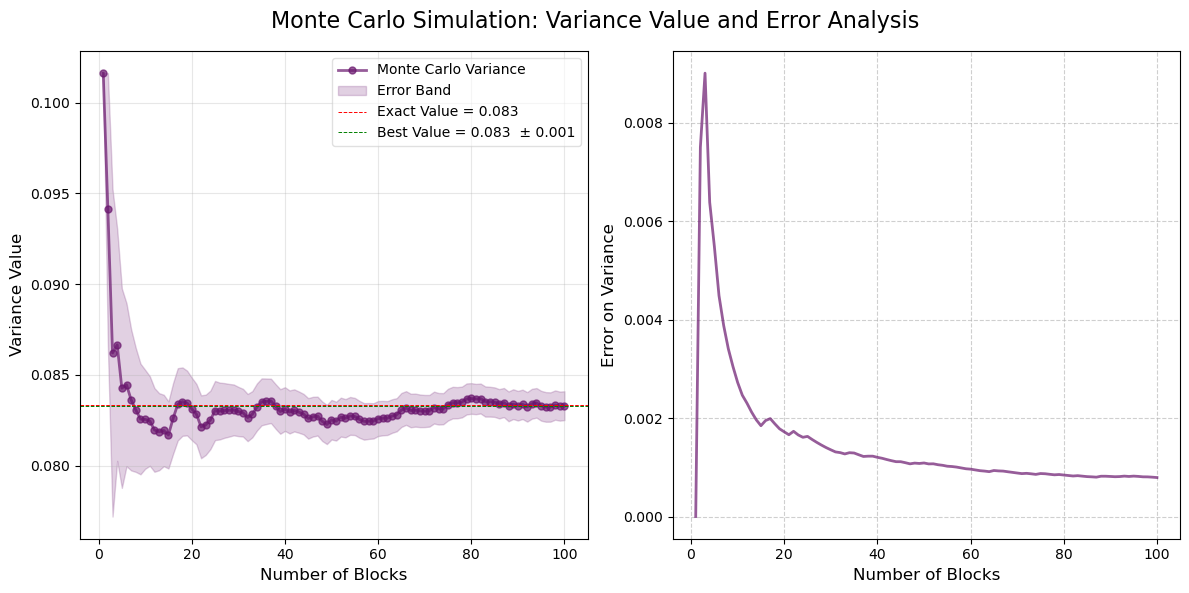

In [4]:
# Variance value and its error
var = "ex01.1/out_var.data"
x1, y1, error1 = np.loadtxt(var, usecols=(0,1,2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt(var, usecols=(0,2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Variance with Error Band
ax[0].plot(x1/100, y1, 'o-', color=color, alpha=0.7, markersize=5, label='Monte Carlo Variance')
ax[0].fill_between(x1/100, y1-error1, y1+error1, color=color, alpha=0.2, label='Error Band')
ax[0].axhline(y=1./12., color='red', linestyle='--', linewidth=0.7, label=f'Exact Value = {1./12.:.3f}')
ax[0].axhline(y=y1[99], color='green', linestyle='--', linewidth=0.7, label=f'Best Value = {y1[99]:.3f}  ± {error1[99]:.3f}')
ax[0].set_xlabel('Number of Blocks')
ax[0].set_ylabel('Variance Value')
ax[0].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x')

# Plot 2: Error on Variance
ax[1].plot(x2/100, y2, color=color, alpha=0.7)
ax[1].set_xlabel('Number of Blocks')
ax[1].set_ylabel('Error on Variance')
ax[1].grid(True, alpha=0.6, linestyle='--')

fig.suptitle('Monte Carlo Simulation: Variance Value and Error Analysis', fontsize=16)

plt.tight_layout()
plt.show()

### $\chi^2 test$

A $\chi^2$ test is performed to make sure that pseudo-numbers generated by the function Rannyu() are distributed uniformly in $[0,1)$. The calculation is executed for $100$, $1000$, $10000$ times and for each iteration $m=100$ is the size of the counts vector (number of sub-intervals in $[0,1)$). We generate $M=10^4$ numbers, scaled by $m$ and rounded to integers to determine the $\chi^2$ bin index. We can write $\chi^2$ as
$$\chi^2 = \sum_{i=1}^M\frac{(n_i-n/M)^2}{n/M} \, ,$$

where the average $(n_i-n/M)^2 \simeq \frac{n}{M}$, leading to $\chi^2 \simeq 100$, due to the binomial distribution behavior, which is exactly the number of sub-intervals. Thanks to CLT, the distribution will converge to a Normal distribution.


<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
/var/folders/5g/cpldmxds2xggtycjntr8y0w00000gn/T/ipykernel_976/3907878674.py:42: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2$ Test for $N \in \{100,1000,10000\}$', fontsize=16)


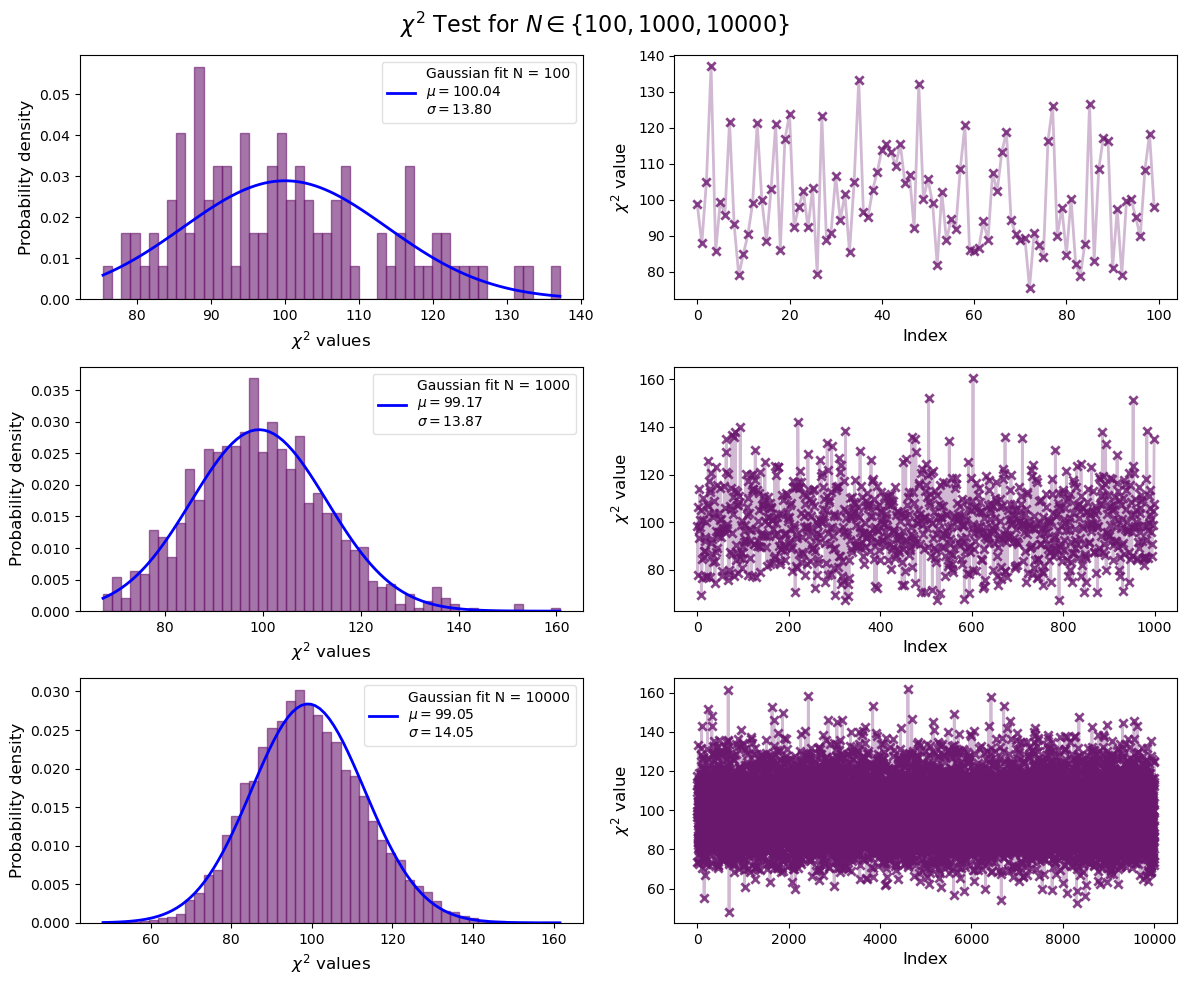

In [6]:
def plot_data(file_chi, ax_index, title, color, bins):
    
    with open(file_chi, 'r') as f:
        data_chi = [float(line.strip()) for line in f]
        
    mu, sigma = norm.fit(data_chi) 

    axs[ax_index, 0].hist(
        data_chi, bins=bins, color=color, alpha=0.6, edgecolor=color, density=True
    )
    axs[ax_index, 0].set_xlabel('$\\chi^2$ values')
    axs[ax_index, 0].set_ylabel('Probability density')
    x_vals = np.linspace(np.min(data_chi), np.max(data_chi), 100)
    y_vals = norm.pdf(x_vals, mu, sigma)
    axs[ax_index, 0].plot(
        x_vals, y_vals,linestyle='-', color='b', 
        label=f'Gaussian fit {title}\n$\\mu = {mu:.2f}$\n$\\sigma = {sigma:.2f}$'
    )
    axs[ax_index, 0].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6)

    axs[ax_index, 1].scatter(
        range(len(data_chi)), data_chi, color=color, marker='x', alpha=0.8
    )
    axs[ax_index, 1].plot(
        range(len(data_chi)), data_chi, linestyle='-', color=color, alpha=0.3
    )
    axs[ax_index, 1].set_xlabel('Index')
    axs[ax_index, 1].set_ylabel('$\\chi^2$ value')


fig, axs = plt.subplots(3, 2, figsize=(12, 10))
files = [
    ('ex01.1/out_chi_100.data', 'N = 100', 50),
    ('ex01.1/out_chi_1000.data', 'N = 1000', 50),
    ('ex01.1/out_chi_10000.data', 'N = 10000', 50)
]

for i, (file_chi, title, bins) in enumerate(files):
    plot_data(file_chi, i, title, color, bins)

fig.suptitle('$\chi^2$ Test for $N \in \{100,1000,10000\}$', fontsize=16)

plt.tight_layout()
plt.show()

### Exercise 01.2
- Extend Pseudo-Random Number generator downloaded from the NSL Ariel web site and check the Central Limit Theorem:

1. Add two probability distributions by using the **method of the inversion of the cumulative distribution** to sample from a **generic** exponential distribution, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Exponential_distribution">this Wikipedia link</a>), and a **generic** Cauchy-Lorentz distribution $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">this Wikipedia link</a>).
2. Make 3 pictures with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).

Note tha you can try to fit the case $N=100$ with a Gaussian for standard and exponential dices, whereas you should use a Cauchy-Lorentz distribution for the last case.

### Inverse Cumulative Method
We used the inverse cumulative method in order to implement the probability distributions $p(x)$ described earlier. By setting a cumulative distribution function $F_x(x)$ equal to a uniform random variable $u \in [0,1)$, it is possible to find $x$ distributed accordingly to the desired $p(x)$, by inverting
$$F(x) = \int_{-\infty}^x p(x')dx' \, ,$$
in fact, by setting $u=F(x)$, we can find $x=F^{-1}(u)$.

### Exponential Distribution Example
If our aim is to generate a random variable $x$ distributed according to the exponential distribution $p(x)=\lambda e^{-\lambda x}$, with $x\in [0,\inf)$, we can start evaluating its cumulative distribution
$$F(x) = \int_0^x \lambda e^{-\lambda x'} dx' = 1-e^{-\lambda x} \, .$$
By setting $u = F(x) = 1 - e^{-\lambda x} \Longrightarrow x = -\frac{1}{\lambda}\ln{(1-u)}$ , where $u$ is uniformly distributed in $[0,1)$, so we can write
$$x = -\frac{1}{\lambda}\ln{(u)} \, .$$ 

### Verification of the CLT

To verify the CLT we generate $M=10^4$ realizations of $S_N = \frac{1}{N} \sum_{i=1}^{N} x_i$, with $N \in {1,2,10,100}$. The single variables $x_i$ are sampled from a uniform, exponential and a Cauchy-Lorentz distribution. We can see that for uniform and exponential distribution, as $N$ gets greater, the distribution of $S_N$ tends to the gaussian distribution. We can't see this behavior for the Cauchy-Lorentz distribution ($\mu = 0$, $\Gamma = 1$) because it doesn't satisfy the CLT's requirements, in fact, it has an infinite variance. The probability density decays according to an inverse power law when $x \rightarrow \infty$
$$p(x) \sim \frac{1}{|x|^{1+\alpha}} \, , \, 0<\alpha<2 \, . $$

<>:57: SyntaxWarning: invalid escape sequence '\i'
<>:57: SyntaxWarning: invalid escape sequence '\i'
/var/folders/5g/cpldmxds2xggtycjntr8y0w00000gn/T/ipykernel_976/1056834921.py:57: SyntaxWarning: invalid escape sequence '\i'
  fig.suptitle('Normal, Exponential and Cauchy-Lorentz Distributions $N \in \{1, 2, 10, 100\}$', fontsize=24)


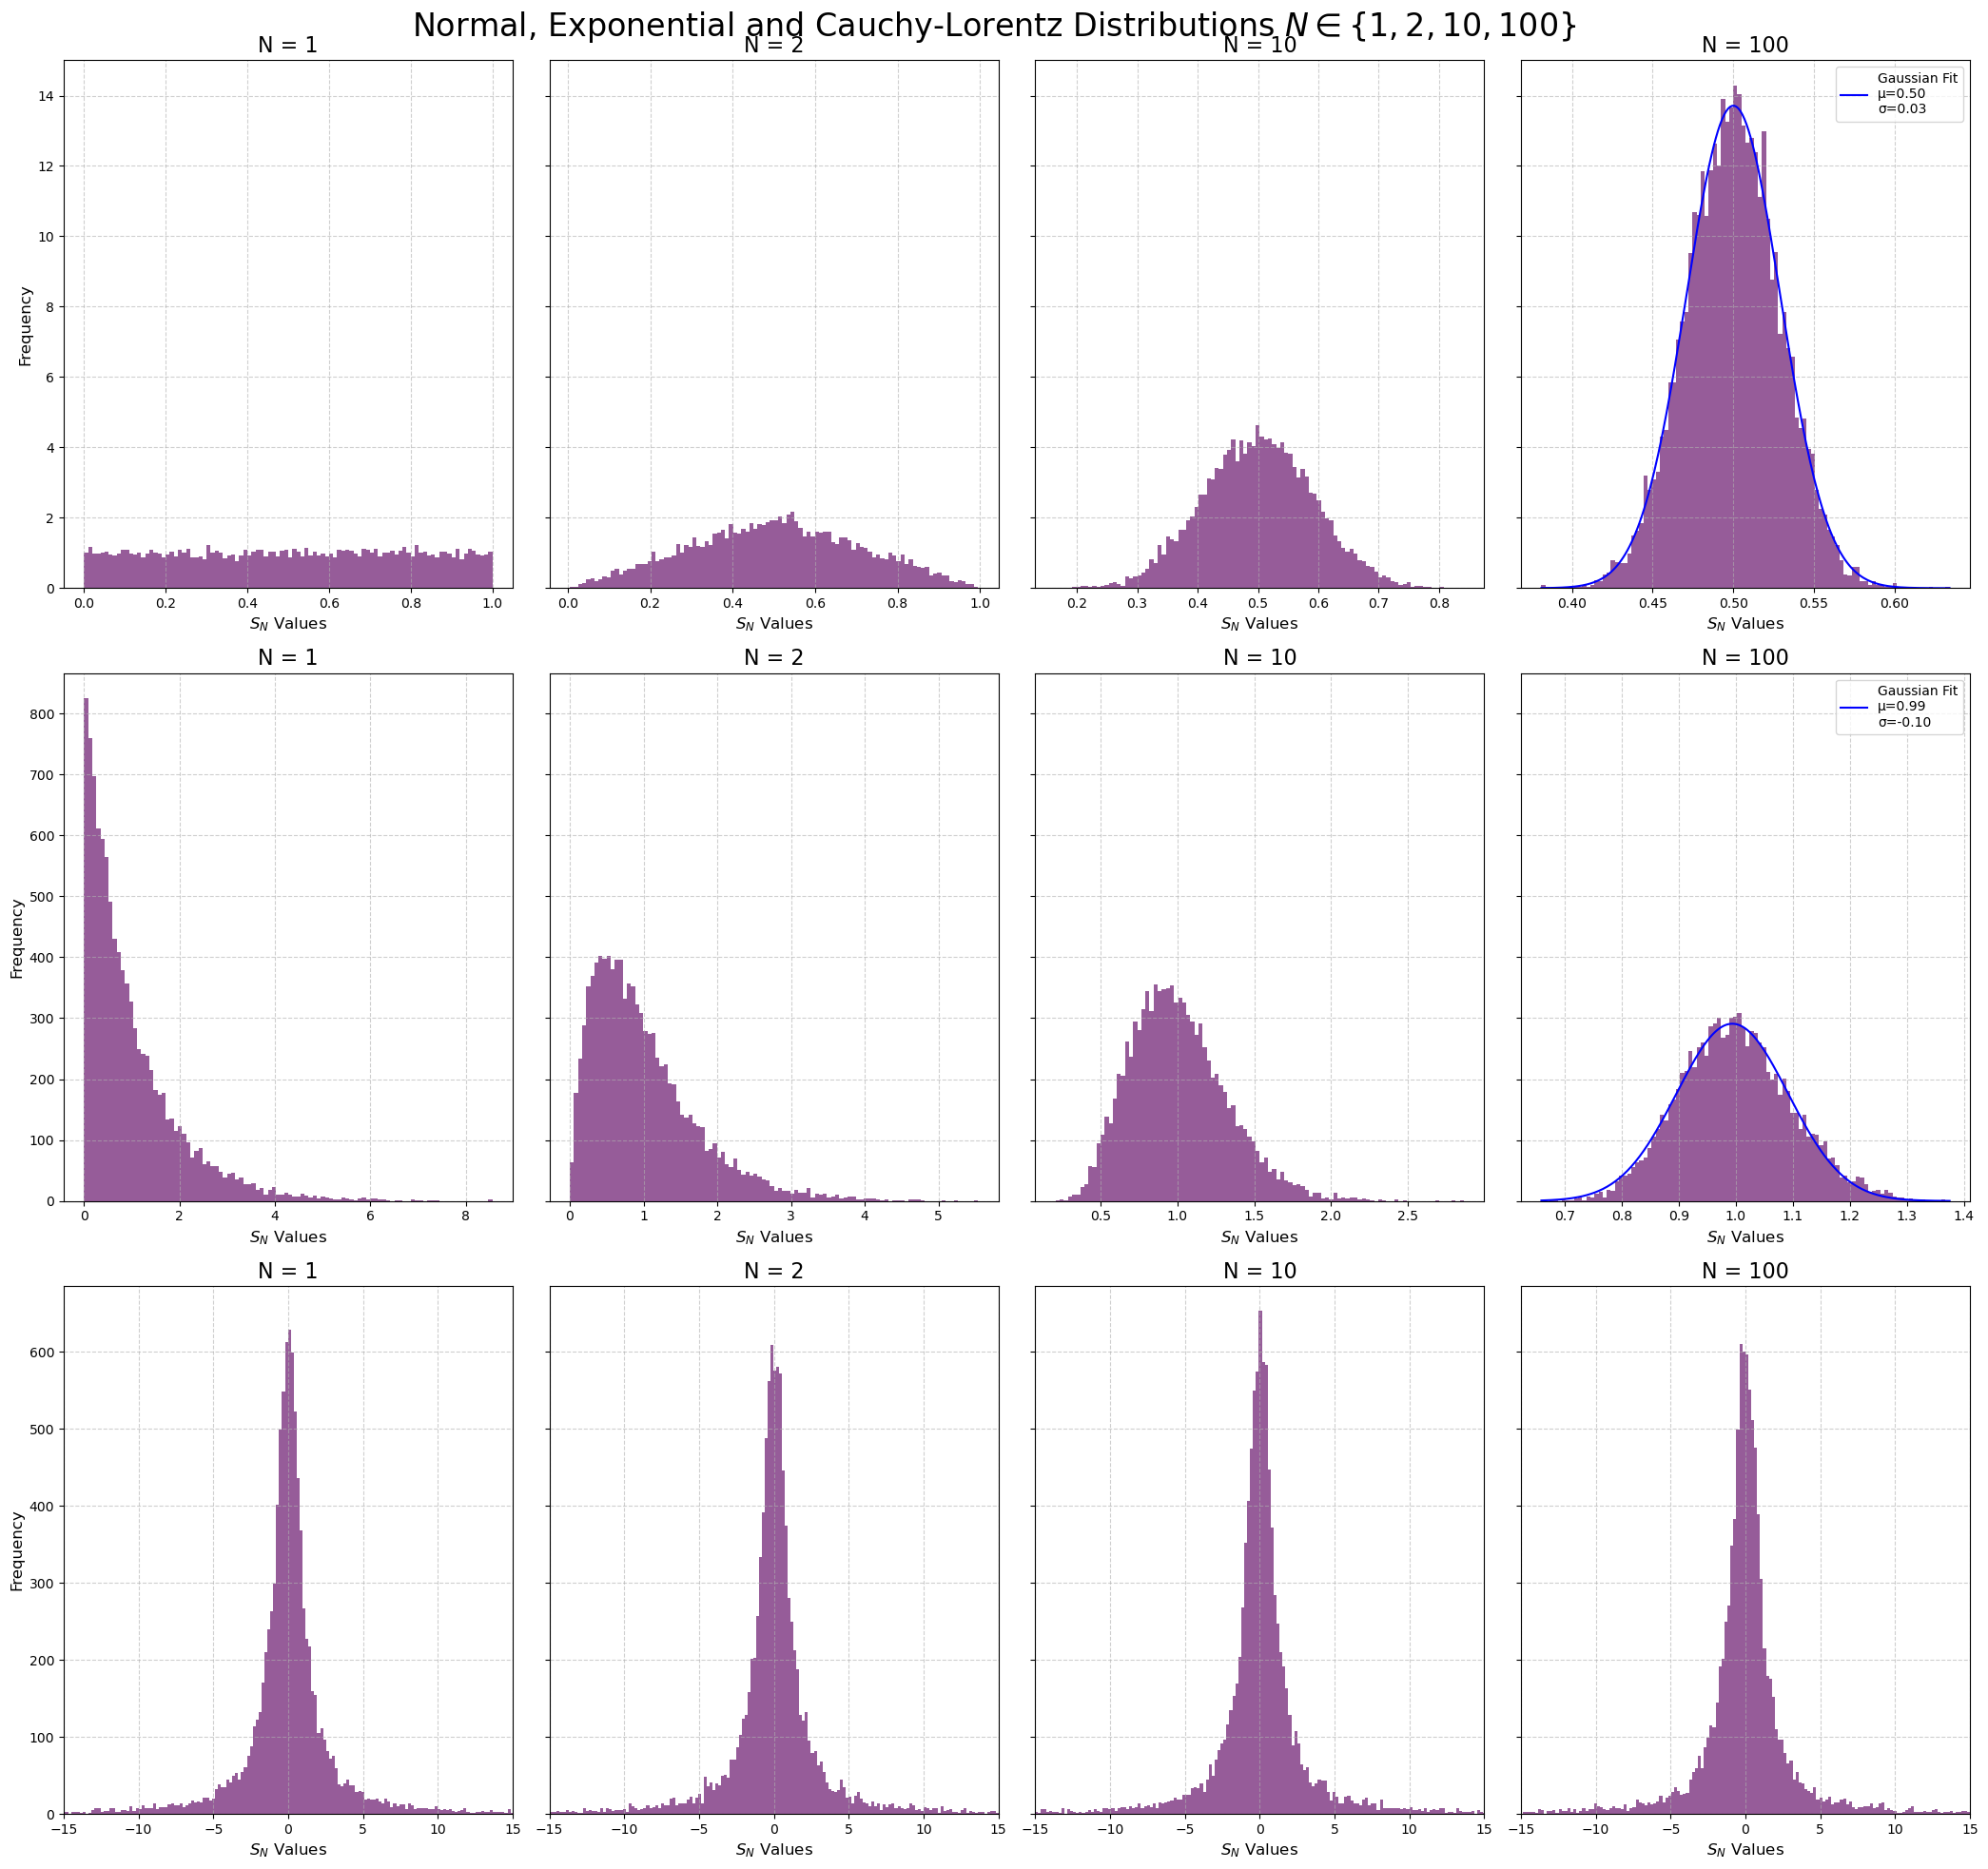

In [19]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

filenames = {
    "1": "ex01.2/out_N1.txt",
    "2": "ex01.2/out_N2.txt",
    "10": "ex01.2/out_N10.txt",
    "100": "ex01.2/out_N100.txt"
}

fig, ax = plt.subplots(3, 4, figsize=(21, 20), sharey='row')

for idx, (N_label, filename) in enumerate(filenames.items()):
    try:
        data = np.loadtxt(filename, skiprows=1)
        hist_data, bins, _ = ax[0, idx].hist(data[:, 0], bins=100, alpha=0.7, color=color, density=True)
        ax[0, idx].set_xlabel("$S_N$ Values")
        ax[0, 0].set_ylabel("Frequency")
        ax[0, idx].set_title(f"N = {N_label}")
        ax[0, idx].grid(True, alpha=0.6, linestyle='--')

        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 0]), np.std(data[:, 0])])
            x = np.linspace(min(data[:, 0]), max(data[:, 0]), 200)
            ax[0, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            ax[0, idx].legend()

        hist_data, bins, _ = ax[1, idx].hist(data[:, 1], bins=100, alpha=0.7, color=color)
        ax[1, idx].set_xlabel("$S_N$ Values")
        ax[1, 0].set_ylabel("Frequency")
        ax[1, idx].set_title(f"N = {N_label}")
        ax[1, idx].grid(True, alpha=0.6, linestyle='--')

        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 1]), np.std(data[:, 1])])
            x = np.linspace(min(data[:, 1]), max(data[:, 1]), 200)
            ax[1, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            ax[1, idx].legend()

        filtered_data = data[:, 2][(data[:, 2] >= -50) & (data[:, 2] <= 50)]
        ax[2, idx].hist(filtered_data, bins=500, alpha=0.7, color=color)
        ax[2, idx].set_xlabel("$S_N$ Values")
        ax[2, 0].set_ylabel("Frequency")
        ax[2, idx].set_xlim(-15., 15.)
        ax[2, idx].set_title(f"N = {N_label}")
        ax[2, idx].grid(True, alpha=0.6, linestyle='--')

    except Exception as e:
        print(f"Error processing {filename}: {e}")

fig.suptitle('Normal, Exponential and Cauchy-Lorentz Distributions $N \in \{1, 2, 10, 100\}$', fontsize=24)
plt.tight_layout()
plt.show()

### Exercise 01.3
- **Simulate** the Buffon’s experiment (see LSN_Lecture_00, supplementary material):  A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ (must be $d > L$, but do not use $d\gg L$ otherwise $P\ll 1$) apart. The probability $P$ that the needle will intersect one of these lines is: $P = 2L/\pi d$. This could be used to evaluate $\pi$ from throws of the needle: if the needle is thrown down $N_{thr}$ times and is observed to land on a line $N_{hit}$ of those times, we can make an estimate of $\pi$ from
$$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$
Make a picture of the estimation of $\pi$ and its uncertainty (Standard Deviation of the mean) with a large number of *throws* $M$ as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties). If possible, do not use $\pi$ to evaluate $\pi$.

### Simulation
We choose as distance between the lines $d=1.0$ and $L=0.8$ as the needle's length. We generate a total number of throws $M=10^4$ divided into $N=100$ blocks, so in each block there are $N_{thr}=100$ throws. For each throw, a random vertical position for the center of the needle  $y_0$ is generated uniformly between $[0,d)$. An orientation $\alpha$ is also generetad following a uniform distribution. We can define the needle's endings coordinates as
$$y_{up} = y_0 + \frac{L}{2} \sin{(\alpha)} \, , \, y_{down} = y_0 , \frac{L}{2} \sin{(\alpha)} \, $$
so if $y_{up} > d$ or $y_{down} < 0$, the needle has crossed a line and we can take $N_{hit} \leftarrow N_{hit}+1$. We can estimate $\pi$ as
$$\pi  \sim \frac{2LN_{thr}}{N_{hit}d} \, .$$

A problem arises when we have to generate $\alpha$. Since the aim of the exercise is to numerically determine $\pi$, we can't use it as a constrain for the $\alpha$ generation. We implement a rejection technique by generating points with coordinates $(x,y)$ within a side $2$ square centered at the origin. Point with $x$, $y$ values such as $x^2+y^2 \geq 1$ are rejected (they fall outside the circle). If accepted, we can calculate $\alpha$ as
$$\alpha = \arccos{\left(\frac{x}{\sqrt{x^2+y^2}}\right)} \, .$$

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/var/folders/5g/cpldmxds2xggtycjntr8y0w00000gn/T/ipykernel_976/2561891996.py:28: SyntaxWarning: invalid escape sequence '\p'
  plt.suptitle("$\pi$ Evaluation with Buffon's Experiment", fontsize=18)


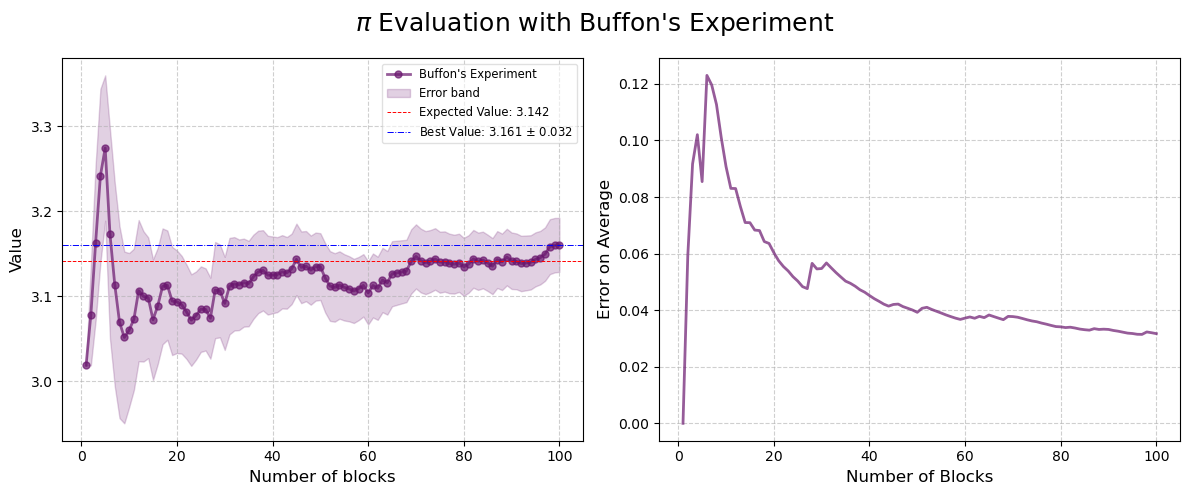

In [23]:
x1, y1, error1 = np.loadtxt("ex01.3/out_avg.data", usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt("ex01.3/out_avg.data", usecols=(0, 2), delimiter='\t', unpack=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x1/100, y1, 'o-', color=color, markersize=5, alpha=0.7, label="Buffon's Experiment")

axes[0].fill_between(x1/100, y1 - error1, y1 + error1,
                     color=color, alpha=0.2, label='Error band')

axes[0].axhline(y=np.pi, color='red', linestyle='--', linewidth=0.7,
                label=rf'Expected Value: {np.pi:.3f}')

axes[0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=0.7,
                label=rf'Best Value: {y1[99]:.3f} $\pm$ {error1[99]:.3f}')

axes[0].set_xlabel('Number of blocks')
axes[0].set_ylabel('Value')
axes[0].legend(loc='upper right', frameon=True, fancybox=True,
               facecolor='white', framealpha=0.6, fontsize='small')
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(x2/100, y2, '-', color=color, alpha=0.7, label='Error')
axes[1].set_xlabel('Number of Blocks')
axes[1].set_ylabel('Error on Average')
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.suptitle("$\pi$ Evaluation with Buffon's Experiment", fontsize=18)
plt.tight_layout()
plt.show()

### Computing statistical uncertainties: the blocking method
- A fundamental step in every Monte Carlo calculation is the estimation of its statistical uncertainty, **it's a must!** Your task would not be completed if you had not calculated it.

 In computing the statistical uncertainties, i.e. the standard deviation of the mean, you need an estimation of the variance $\sigma^2$, the second central moment. First of all note that the variance can be computed from
    $$\sigma^2_A := \langle (A-\langle A\rangle)^2\rangle = \langle A^2 \rangle -\langle A\rangle^2 $$
    What is the best way to estimate $\sigma^2_A$? Imagine that your Monte Carlo estimation of $A$ is obtained from a calculation which uses $M$ Monte Carlo "steps" (intentionally, here I am generic because what is a single "step" in a Monte Carlo calculation strictly depends on the specific calculation); you can always divide such $M$ Monte Carlo "steps" in $N$ blocks, with $N<M$. In each block, you can use your $M/N$ Monte Carlo "steps" to obtain an estimate of $A$, let me call it $A_i$ with $i=1,N$, and then you have also $A^2_i$ with $i=1,N$.
    At this point everything becomes clear:
    $$ \langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 $$
    and finally the statistical uncertainty with $N$ :
    $$\frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$

- In a Monte Carlo calculation, you can use the arguments above to outputting an estimate of A and its statistical uncertainty on the fly, during your calculation. You will be able to do this every $M/N$ steps, and thus, in the end, $N$ times. Note that after the first $M/N$ Monte Carlo steps, at the end of the first block, your estimation of the uncertainty is not computable, so set it to zero and compute it only from the second block. **Question**: $N$ can be chosen in many ways ... what are the limitations regarding this choice?